In [1]:
import numpy as np
import pandas as pd
#import tensorflow as tf
from matplotlib import pyplot as plt
#import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from torch.utils.data import TensorDataset, DataLoader, random_split

import torch.optim as optim
import torch.nn as nn

from tqdm import tqdm

import torch.nn.functional as F
import time
from datetime import timedelta

Nr = 16 # Nombre d'éléments

# The following lines adjust the granularity of reporting.
pd.options.display.max_rows = 10
pd.options.display.float_format = "{:.1f}".format

# 1. Chargement
# Chargement des Data
input_signals = np.load("../Data/X_mvdr_300k.npy")  # Shape attendue: (100000, 3)
output_signals = np.load("../Data/Y_mvdr_300k.npy") # Shape attendue: (100000, 32)

# 2. NORMALISATION DES POIDS (Y)
# On calcule la norme de chaque ligne (chaque vecteur de 32 éléments)
# La norme d'un vecteur complexe w est sqrt(sum(Re^2 + Im^2))
normes = np.linalg.norm(output_signals, axis=1, keepdims=True)
output_signals = output_signals / normes

# 3. NORMALISATION DES ANGLES (X)
input_x = torch.from_numpy(input_signals).float() / 60.0
output_x = torch.from_numpy(output_signals).float()

print(f"Poids normalisés. Nouvelle norme moyenne : {torch.norm(output_x[0]):.4f}")
print(input_x.shape)
print(output_x.shape)

Poids normalisés. Nouvelle norme moyenne : 1.0000
torch.Size([300000, 3])
torch.Size([300000, 32])


In [2]:
# des couches de taille multiple de 32       #<---------------------------------------------
class MVDR_FFNN(nn.Module):
    def __init__(self):
        super(MVDR_FFNN, self).__init__()
        self.layer1 = nn.Linear(3, 512)
        self.layer2 = nn.Linear(512, 512)
        self.layer3 = nn.Linear(512, 1024)
        self.layer4 = nn.Linear(1024, 512)
        self.layer5 = nn.Linear(512, 32) # Dernière couche 
        
    def forward(self, x):
        # 1. Les L-1 premières couches cachées utilisent Tanh ou leaky_relu  x = F.leaky_relu(self.layer1(x), 0.1)
        x = F.leaky_relu(self.layer1(x), 0.1)
        x = F.leaky_relu(self.layer2(x), 0.1)
        x = F.leaky_relu(self.layer3(x), 0.1)
        x = F.leaky_relu(self.layer4(x), 0.1)
               
        x = self.layer5(x)        
        return x

class RMSELoss(nn.Module):      #<---------------------------------------------
    def __init__(self, eps=1e-8):
        super().__init__()
        self.mse = nn.MSELoss()
        self.eps = eps

    def forward(self, y_hat, y):
        loss = torch.sqrt(self.mse(y_hat, y) + self.eps)
        return loss

# =================================================================================================================

# =================================================================================================================

# Device cuda
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Model
model = MVDR_FFNN().to(device)
print(model)

# 1. Création du Dataset complet
dataset = TensorDataset(input_x, output_x)

# 2. Division : 80% train, 20% validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# 3. Création des DataLoaders
# shuffle=True est CRUCIAL pour que le réseau ne s'habitue pas à l'ordre des données
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True,  pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False) #<---------------------------------------------

# Utilisation de la MSE (Mean Squared Error) pour comparer les poids
criterion = RMSELoss()

# AdamW avec un Learning Rate standard
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)        #<---------------------------------------------

# =================================================================================================================

# =================================================================================================================

# Optionnel : Un scheduler pour réduire le LR si la perte stagne
# (Aide à obtenir des "nuls" plus profonds à la fin de l'entraînement)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

# Initialisation
train_losses = []
test_losses = []
epochs = 300  #<---------------------------------------------

# Configuration du Scheduler Cosine
# Il va descendre de façon fluide sans les "marches d'escalier"
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-7)

start_time = time.time()  # On lance le chrono global
print(f" Début de l'entraînement à : {time.strftime('%H:%M:%S')}")

for epoch in range(epochs):
    # --- PHASE D'ENTRAÎNEMENT ---
    model.train()
    running_train_loss = 0.0
    # On garde tqdm pour la barre de progression par époque
    loop = tqdm(train_loader, desc=f"Époque [{epoch+1}/{epochs}]", leave=False)
    
    for inputs, targets in loop:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        
        outputs = model(inputs)        
        loss = criterion(outputs, targets)        
        loss.backward()       
        optimizer.step()       
        
        running_train_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.2e}")

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # --- PHASE DE TEST (VALIDATION) ---
    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader: 
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_test_loss += loss.item()
    
    epoch_test_loss = running_test_loss / len(val_loader)
    test_losses.append(epoch_test_loss)
    
    # Mise à jour du scheduler Cosine (automatique à chaque époque)
    scheduler.step()

    # Récupération du LR actuel pour le suivi
    current_lr = optimizer.param_groups[0]['lr']

    # AFFICHAGE (Indenté à l'intérieur de la boucle pour voir l'évolution)
    # On affiche toutes les époques (ou tu peux mettre un if epoch % 10 == 0:)
    if epoch % 10 == 0:
        print(f"Époque [{epoch+1}/{epochs}] | Train: {epoch_train_loss:.6f} | Test: {epoch_test_loss:.6f} | LR: {current_lr:.2e}")

# Calcul du temps total de l'entrainement.
end_time = time.time()
total_duration_seconds = end_time - start_time

# Conversion magique en Heures:Minutes:Secondes
total_time_str = str(timedelta(seconds=int(total_duration_seconds)))

print("-" * 50)
print(f"✅ ENTRAÎNEMENT TERMINÉ")
print(f"⏱️ TEMPS TOTAL : {total_time_str} (HH:MM:SS)")
print("-" * 50)
        

MVDR_FFNN(
  (layer1): Linear(in_features=3, out_features=512, bias=True)
  (layer2): Linear(in_features=512, out_features=512, bias=True)
  (layer3): Linear(in_features=512, out_features=1024, bias=True)
  (layer4): Linear(in_features=1024, out_features=512, bias=True)
  (layer5): Linear(in_features=512, out_features=32, bias=True)
)
 Début de l'entraînement à : 16:30:51


Époque [1/300] | Train: 0.093507 | Test: 0.059783 | LR: 1.00e-03


Époque [11/300] | Train: 0.021773 | Test: 0.023467 | LR: 9.97e-04


Époque [21/300] | Train: 0.018673 | Test: 0.022036 | LR: 9.88e-04


Époque [31/300] | Train: 0.016372 | Test: 0.015210 | LR: 9.74e-04


...

Époque [261/300] | Train: 0.006957 | Test: 0.007166 | LR: 4.12e-05


Époque [271/300] | Train: 0.006903 | Test: 0.007109 | LR: 2.30e-05


Époque [281/300] | Train: 0.006865 | Test: 0.007078 | LR: 9.96e-06


Époque [291/300] | Train: 0.006840 | Test: 0.007060 | LR: 2.32e-06


--------------------------------------------------
✅ ENTRAÎNEMENT TERMINÉ
⏱️ TEMPS TOTAL : 0:19:04 (HH:MM:SS)
--------------------------------------------------


✅ Graphique sauvegardé : ../models_FFNN/MVDR_FFNN20260331_1650_loss_comparison.png
💾 MODÈLE SAUVEGARDÉ : ../models_FFNN/MVDR_FFNN20260331_1650_model.pth


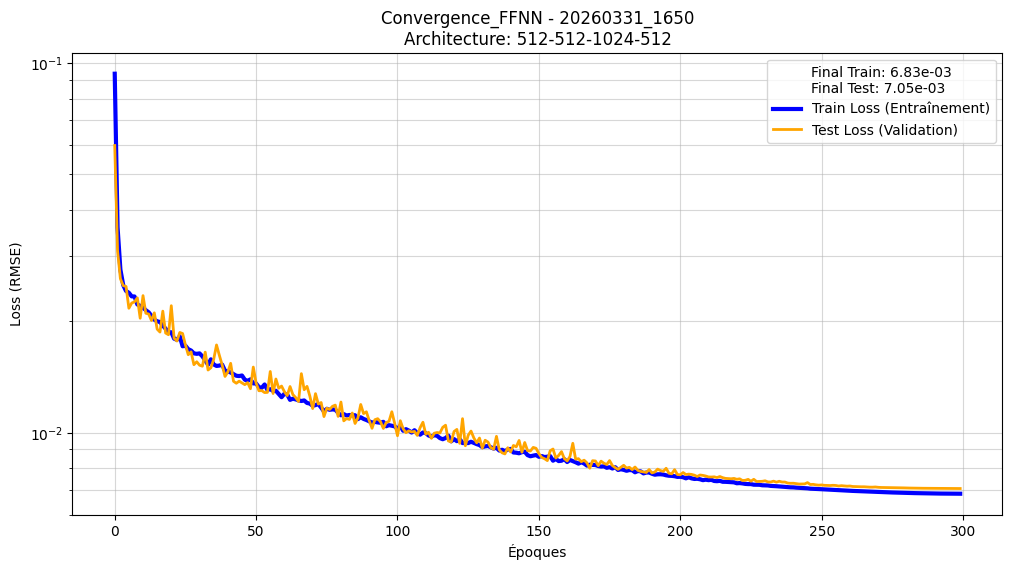

✅ Graphique sauvegardé : ../models_FFNN/MVDR_FFNN20260331_1650_loss_comparison.png


In [3]:
import os
from datetime import datetime
import matplotlib.pyplot as plt

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
base_filename = f"MVDR_FFNN{timestamp}"

# --- AJOUT POUR SAUVEGARDER LES POIDS DU MODÈLE ---
model_filename = f"{base_filename}_model.pth"
folder_name = "../models_FFNN"
model_path = os.path.join(folder_name, model_filename)
plot_path = os.path.join(folder_name, f"{base_filename}_loss_comparison.png")

# Sauvegarde des poids (state_dict)
torch.save(model.state_dict(), model_path)

print(f"✅ Graphique sauvegardé : {plot_path}")
print(f"💾 MODÈLE SAUVEGARDÉ : {model_path}") # <--- Très important !

# 1. RÉACTIVER L'AFFICHAGE (Annule le mode "Agg")
%matplotlib inline 

# 2. REDÉFINIR LES CHEMINS (Pour éviter le NameError)

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# 3. TRACÉ DE LA COURBE
plt.figure(figsize=(12, 6))

plt.plot(train_losses, label='Train Loss (Entraînement)', color='blue', linewidth=3)
plt.plot(test_losses, label='Test Loss (Validation)', color='orange', linewidth=2)

plt.yscale('log') 
plt.title(f"Convergence_FFNN - {timestamp}\nArchitecture: 512-512-1024-512", fontsize=12)
plt.xlabel("Époques")
plt.ylabel("Loss (RMSE)")
plt.grid(True, which="both", alpha=0.5)

# Légende avec les scores finaux
last_train = train_losses[-1]
last_test = test_losses[-1]
plt.legend(title=f"Final Train: {last_train:.2e}\nFinal Test: {last_test:.2e}", loc='upper right')

# 4. SAUVEGARDE ET AFFICHAGE
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show() # Maintenant ça va s'afficher car on a mis %matplotlib inline
# plt.close() # Optionnel si tu veux garder l'image visible dans le notebook

print(f"✅ Graphique sauvegardé : {plot_path}")